### Spark connect to server

In [51]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.remote("sc://localhost").getOrCreate()
spark

### Load a csv file

In [52]:
import os
os.getcwd()

'/home/analytics4220/Ba'

In [53]:
df = spark.read.csv("/home/analytics4220/Ba/Jobs_data.csv", header=True, inferSchema=True)

### List of columns

In [54]:
print(df.columns)

['FIPS', 'State', 'County', 'UnempRate2021', 'PctEmpChange2021', 'UnempRate2020', 'PctEmpChange1920', 'UnempRate2019', 'UnempRate2018', 'UnempRate2017', 'UnempRate2016', 'UnempRate2015', 'UnempRate2010', 'UnempRate2007', 'PctEmpChange1021', 'PctEmpChange0721', 'PctEmpChange0710', 'PctEmpAgriculture', 'PctEmpMining', 'PctEmpConstruction', 'PctEmpManufacturing', 'PctEmpTrade', 'PctEmpTrans', 'PctEmpInformation', 'PctEmpFIRE', 'PctEmpServices', 'PctEmpGovt', 'NumCivEmployed', 'NumCivLaborForce2008', 'NumUnemployed2012', 'NumEmployed2012', 'UnempRate2012', 'NumCivLaborForce2012', 'UnempRate2009', 'NumUnemployed2011', 'NumCivLaborForce2009', 'NumCivLaborForce2011', 'NumEmployed2014', 'NumEmployed2008', 'UnempRate2011', 'NumUnemployed2020', 'NumEmployed2020', 'NumCivLaborForce2020', 'NumUnemployed2008', 'NumUnemployed2009', 'NumEmployed2009', 'NumCivLaborforce2007', 'UnempRate2008', 'NumEmployed2011', 'NumCivLaborforce2017', 'NumUnemployed2021', 'NumEmployed2021', 'NumCivLaborforce2021', 'Nu

### Select necessary columns

In [59]:
df = df.select(df['State'], df['County'], df['NumUnemployed2019'],df['NumUnemployed2020'],df['NumUnemployed2021'],df['NumCivLaborforce2019'],df['NumCivLaborforce2020'],df['NumCivLaborforce2021'])
df.show()

+-----+-------------+-----------------+-----------------+-----------------+--------------------+--------------------+--------------------+
|State|       County|NumUnemployed2019|NumUnemployed2020|NumUnemployed2021|NumCivLaborforce2019|NumCivLaborforce2020|NumCivLaborforce2021|
+-----+-------------+-----------------+-----------------+-----------------+--------------------+--------------------+--------------------+
|   US|United States|          6009990|         13023736|          8658650|           163815890|           161207103|           161758337|
|   AL|      Alabama|            72024|           147160|            77272|             2271892|             2268309|             2246993|
|   AL|      Autauga|              764|             1420|              742|               26684|               26405|               26341|
|   AL|      Baldwin|             2877|             6159|             2946|               98921|               98910|               99427|
|   AL|      Barbour|      

### Filter necessary rows 

In [56]:
from pyspark.sql import functions as F
df_states = df.filter(
    ((F.col('State') == 'NV') & (F.col('County') == 'Nevada')) | 
    ((F.col('State') == 'HI') & (F.col('County') == 'Hawaii')) |
    ((F.col('State') == 'CA') & (F.col('County') == 'California')) |
    ((F.col('State') == 'WA') & (F.col('County') == 'Washington'))
)
df_states.show()

+-----+----------+-----------------+-----------------+-----------------+--------------------+--------------------+--------------------+
|State|    County|NumUnemployed2019|NumUnemployed2020|NumUnemployed2021|NumCivLaborforce2019|NumCivLaborforce2020|NumCivLaborforce2021|
+-----+----------+-----------------+-----------------+-----------------+--------------------+--------------------+--------------------+
|   CA|California|           796806|          1934450|          1381250|            19409413|            18931116|            18923194|
|   HI|    Hawaii|            16776|            79512|            38226|              684690|              662491|              668413|
|   NV|    Nevada|            61995|           203208|           108822|             1541772|             1502848|             1504761|
|   WA|Washington|           169140|           332663|           204775|             3933774|             3929477|             3913513|
+-----+----------+-----------------+------------

### Create UnemploymentRate column = NumUnemployed column / NumCivlLaborforce column

In [57]:
from pyspark.sql import functions as F
df_div = df_states.withColumns({
    'UnemployedRate2019': F.round(F.col('NumUnemployed2019') / F.col('NumCivLaborforce2019') * 100,2),
    'UnemployedRate2020': F.round(F.col('NumUnemployed2020') / F.col('NumCivLaborforce2020') * 100,2),
    'UnemployedRate2021': F.round(F.col('NumUnemployed2021') / F.col('NumCivLaborforce2021') * 100,2)
                            })
df_div.show()

+-----+----------+-----------------+-----------------+-----------------+--------------------+--------------------+--------------------+------------------+------------------+------------------+
|State|    County|NumUnemployed2019|NumUnemployed2020|NumUnemployed2021|NumCivLaborforce2019|NumCivLaborforce2020|NumCivLaborforce2021|UnemployedRate2019|UnemployedRate2020|UnemployedRate2021|
+-----+----------+-----------------+-----------------+-----------------+--------------------+--------------------+--------------------+------------------+------------------+------------------+
|   CA|California|           796806|          1934450|          1381250|            19409413|            18931116|            18923194|              4.11|             10.22|               7.3|
|   HI|    Hawaii|            16776|            79512|            38226|              684690|              662491|              668413|              2.45|              12.0|              5.72|
|   NV|    Nevada|            61995

In [58]:
df_rate = df_div.select(df_div['State'], df_div['County'], df_div['UnemployedRate2019'],df_div['UnemployedRate2020'],df_div['UnemployedRate2021'])
df_rate.show()

+-----+----------+------------------+------------------+------------------+
|State|    County|UnemployedRate2019|UnemployedRate2020|UnemployedRate2021|
+-----+----------+------------------+------------------+------------------+
|   CA|California|              4.11|             10.22|               7.3|
|   HI|    Hawaii|              2.45|              12.0|              5.72|
|   NV|    Nevada|              4.02|             13.52|              7.23|
|   WA|Washington|               4.3|              8.47|              5.23|
+-----+----------+------------------+------------------+------------------+



### plot the bar chart of unemployment rate

<Axes: xlabel='State'>

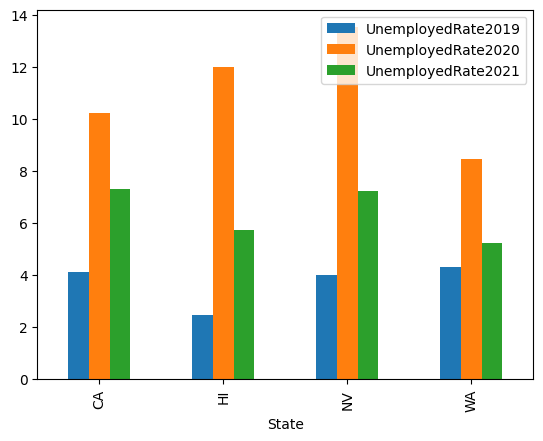

In [61]:
df_rate.toPandas().plot.bar(x ='State')